In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi

# =========================
# Two-body decay generator
# =========================

def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df   

# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937,
    "Phi" : 1.02
}


# =========================
# Generate datasets
# =========================

N = 10000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

#Phi decays
df_list.append(two_body_decay(N, masses["Phi"], masses["K"], masses["K"], "Phi→KK"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))


df_list[0]


,process,E1,px1,py1,pz1,E2,px2,py2,pz2
0,Jpsi→pp,1.54845,1.161433,-0.146845,0.383878,1.54845,-1.161433,0.146845,-0.383878
1,Jpsi→pp,1.54845,0.579936,-0.166828,1.074103,1.54845,-0.579936,0.166828,-1.074103
2,Jpsi→pp,1.54845,-0.062066,-1.043175,0.652523,1.54845,0.062066,1.043175,-0.652523
3,Jpsi→pp,1.54845,0.678591,0.007404,1.028257,1.54845,-0.678591,-0.007404,-1.028257
4,Jpsi→pp,1.54845,0.236763,-1.087300,0.528749,1.54845,-0.236763,1.087300,-0.528749
...,...,...,...,...,...,...,...,...,...
9995,Jpsi→pp,1.54845,-1.084908,0.391486,-0.433090,1.54845,1.084908,-0.391486,0.433090
9996,Jpsi→pp,1.54845,0.963785,-0.596119,0.483337,1.54845,-0.963785,0.596119,-0.483337
9997,Jpsi→pp,1.54845,-0.444170,1.101042,0.329049,1.54845,0.444170,-1.101042,-0.329049
9998,Jpsi→pp,1.54845,-0.579392,0.522882,-0.953285,1.54845,0.579392,-0.522882,0.953285


# Smearing section and energy recomputing


In [232]:
#Smearing
def smear_momentum(df, sigma_rel=0.01):
    for comp in ["px1", "py1", "pz1", "px2", "py2", "pz2"]:
        sigma = sigma_rel * np.abs(df[comp])
        df[comp] = np.random.normal(df[comp], sigma)

    return df

mass_map = {
    "Jpsi→pp": (masses["p"], masses["p"]),
    "Jpsi→mumu": (masses["mu"], masses["mu"]),
    "Jpsi→ee": (masses["e"], masses["e"]),
    "Psip→mumu": (masses["mu"], masses["mu"]),
    "Phi→KK": (masses["K"], masses["K"]),
    "γγ→mumu": (masses["mu"], masses["mu"]),
    "γγ→ee": (masses["e"], masses["e"]),
    "γγ→KK": (masses["K"], masses["K"]),
}

df["p1"] = np.sqrt(df["px1"]**2 + df["py1"]**2 + df["pz1"]**2)
df["p2"] = np.sqrt(df["px2"]**2 + df["py2"]**2 + df["pz2"]**2)

# Apply smearing
df = smear_momentum(df, sigma_rel=0.02)  # 2% resolution

def recompute_all_energies(df):
    for proc, (m1, m2) in mass_map.items():
        mask = df["process"] == proc

        p1_sq = df.loc[mask, ["px1","py1","pz1"]].pow(2).sum(axis=1)
        p2_sq = df.loc[mask, ["px2","py2","pz2"]].pow(2).sum(axis=1)

        df.loc[mask, "E1"] = np.sqrt(p1_sq + m1**2)
        df.loc[mask, "E2"] = np.sqrt(p2_sq + m2**2)

    return df


df = pd.concat(df_list, ignore_index=True)

df_before = df.copy()

df_after = smear_momentum(df.copy(), sigma_rel= 0.04)
df_after = recompute_all_energies(df_after)

# Momentum comparisons

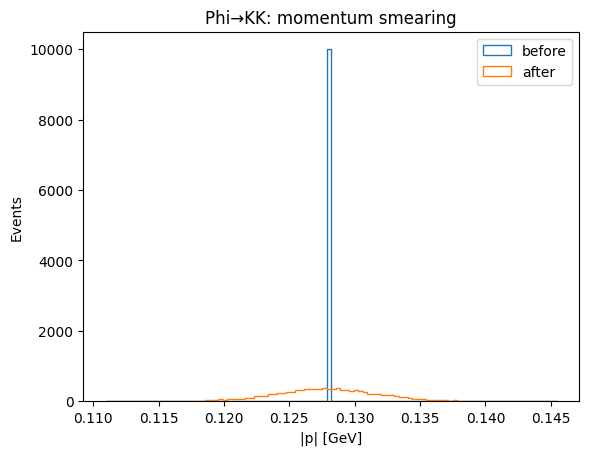

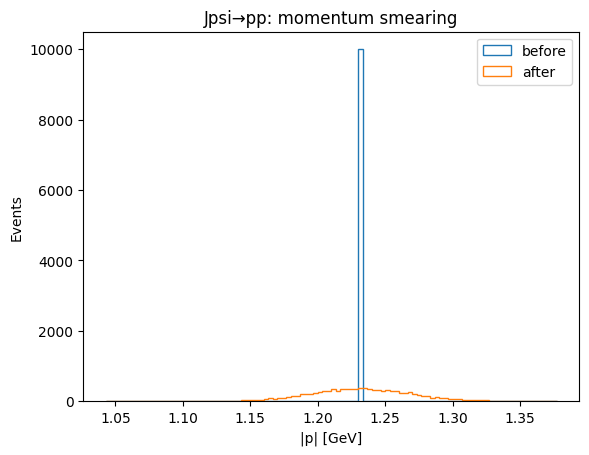

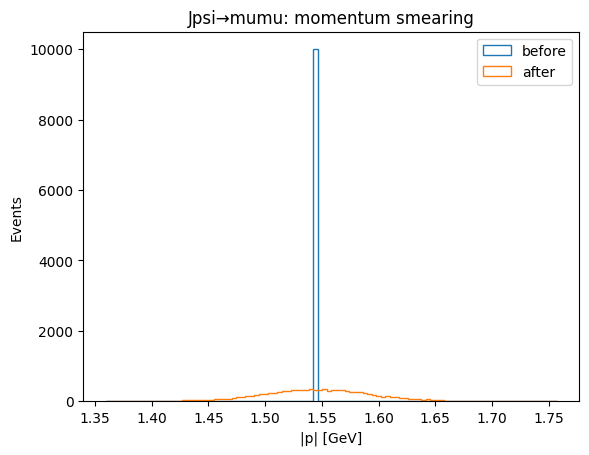

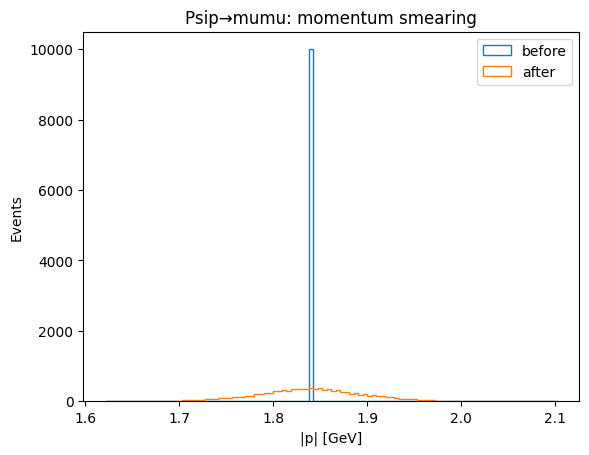

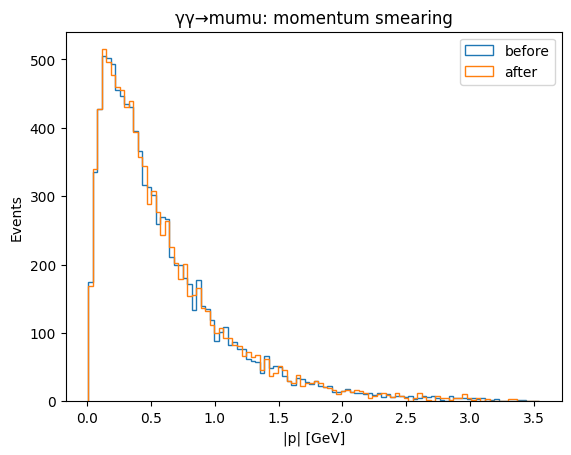

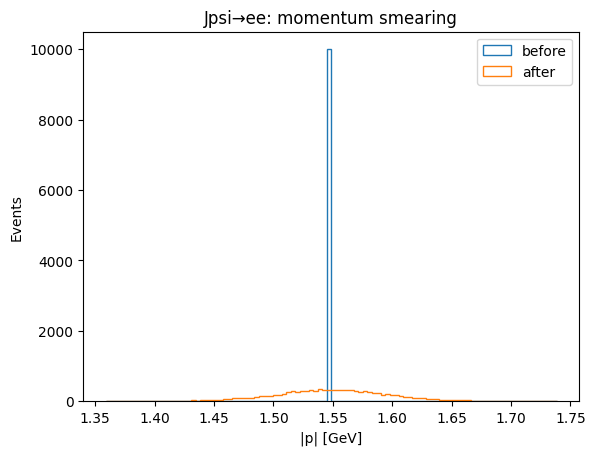

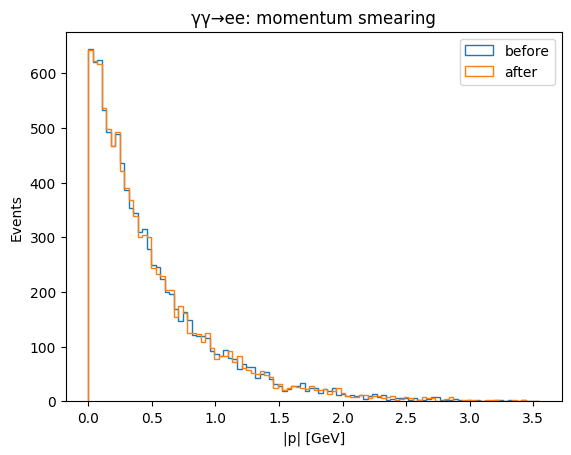

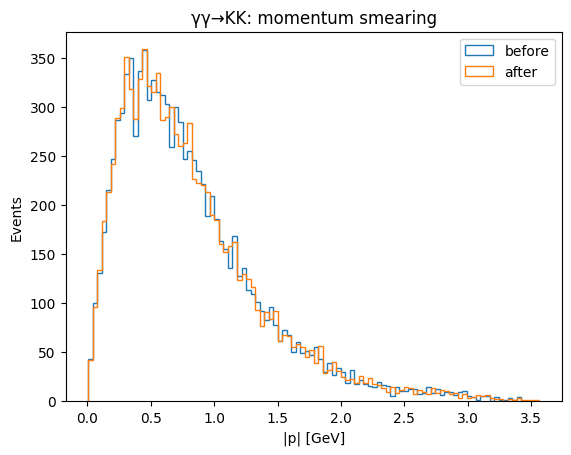

In [233]:
def plot_momentum_comparison(df_before, df_after, process):

    b = df_before[df_before["process"] == process]
    a = df_after[df_after["process"] == process]

    # compute |p|
    p1_b = np.sqrt(b["px1"]**2 + b["py1"]**2 + b["pz1"]**2)
    p1_a = np.sqrt(a["px1"]**2 + a["py1"]**2 + a["pz1"]**2)

    # clean
    p1_b = p1_b.replace([np.inf, -np.inf], np.nan).dropna()
    p1_a = p1_a.replace([np.inf, -np.inf], np.nan).dropna()

    if len(p1_b) == 0 or len(p1_a) == 0:
        print(f"{process}: no data")
        return

    # check spread
    pmin = min(p1_b.min(), p1_a.min())
    pmax = max(p1_b.max(), p1_a.max())

    if np.isclose(pmin, pmax):
        # ultra-narrow → use fixed small window
        center = pmin
        width = 0.01  # GeV (tune if needed)
        bins = 30
        hist_range = (center - width, center + width)
    else:
        bins = min(100, int(np.sqrt(len(p1_b))))
        hist_range = (pmin, pmax)

    plt.hist(p1_b, bins=bins, range=hist_range, histtype="step", label="before")
    plt.hist(p1_a, bins=bins, range=hist_range, histtype="step", label="after")

    plt.xlabel("|p| [GeV]")
    plt.ylabel("Events")
    plt.title(f"{process}: momentum smearing")
    plt.legend()
    plt.show()

plot_momentum_comparison(df_before, df_after, "Phi→KK")
plot_momentum_comparison(df_before, df_after, "Jpsi→pp")
plot_momentum_comparison(df_before, df_after, "Jpsi→mumu")
plot_momentum_comparison(df_before, df_after, "Psip→mumu")
plot_momentum_comparison(df_before, df_after, "γγ→mumu")
plot_momentum_comparison(df_before, df_after, "Jpsi→ee")
plot_momentum_comparison(df_before, df_after, "γγ→ee")
plot_momentum_comparison(df_before, df_after, "γγ→KK")

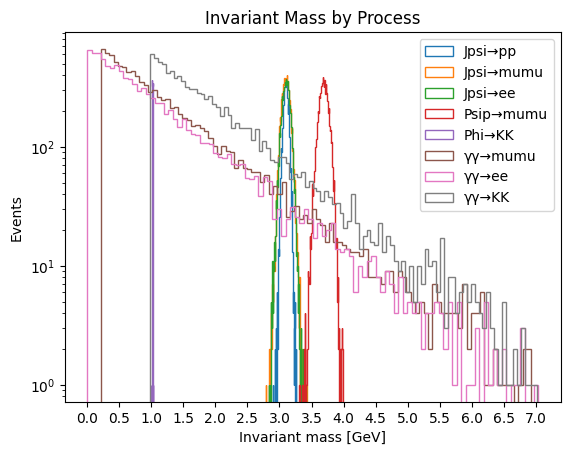

In [234]:
m2 = (
    (df_after["E1"] + df_after["E2"])**2
    - (df_after["px1"] + df_after["px2"])**2
    - (df_after["py1"] + df_after["py2"])**2
    - (df_after["pz1"] + df_after["pz2"])**2
)

df_after["m_inv"] = np.sqrt(np.maximum(m2, 0))

for proc in df_after["process"].unique():
    subset = df_after[df_after["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()